<a href="https://colab.research.google.com/github/nagasailakshmiMaddala/PRODIGY_DS_04/blob/main/PRODIGY_DS_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import zipfile
import os

# Define the path to the zipped file
zip_file_path = '/content/twitter_training.csv.zip'
output_dir = '/content/'

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(output_dir)

# Assuming the unzipped file is twitter_training.csv based on the zip file name
csv_file_path = os.path.join(output_dir, 'twitter_training.csv')

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(csv_file_path)

# Display the first 5 rows of the DataFrame
display(df.head())

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [ ]:
print('DataFrame Info:')
df.info()

print('\nColumn Names:')
print(df.columns)

print('\nMissing Values:')
print(df.isnull().sum())

# Rename columns for clarity based on the head output
df.columns = ['Tweet_ID', 'Entity', 'Sentiment', 'Tweet_text']
df.head()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Tweet_ID    74681 non-null  int64 
 1   Entity      74681 non-null  object
 2   Sentiment   74681 non-null  object
 3   Tweet_text  73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB

Column Names:
Index(['Tweet_ID', 'Entity', 'Sentiment', 'Tweet_text'], dtype='object')

Missing Values:
Tweet_ID        0
Entity          0
Sentiment       0
Tweet_text    686
dtype: int64


,Tweet_ID,Entity,Sentiment,Tweet_text
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [ ]:
# Drop rows where 'Tweet_text' is null, as it's essential for sentiment analysis
df.dropna(subset=['Tweet_text'], inplace=True)

print('Missing values after dropping rows:')
print(df.isnull().sum())

# Display the distribution of sentiments
print('\nSentiment Distribution:')
print(df['Sentiment'].value_counts())

Missing values after dropping rows:
Tweet_ID      0
Entity        0
Sentiment     0
Tweet_text    0
dtype: int64

Sentiment Distribution:
Sentiment
Negative      22358
Positive      20654
Neutral       18108
Irrelevant    12875
Name: count, dtype: int64


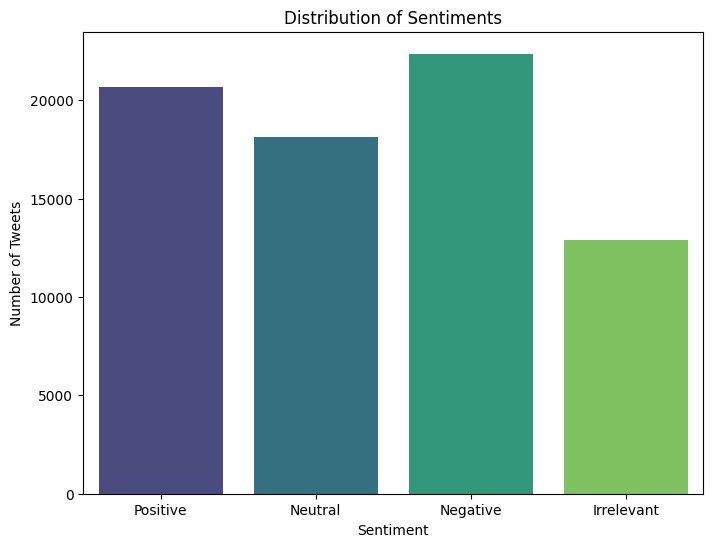

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the sentiment distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='Sentiment', data=df, palette='viridis', hue='Sentiment', legend=False)
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.show()

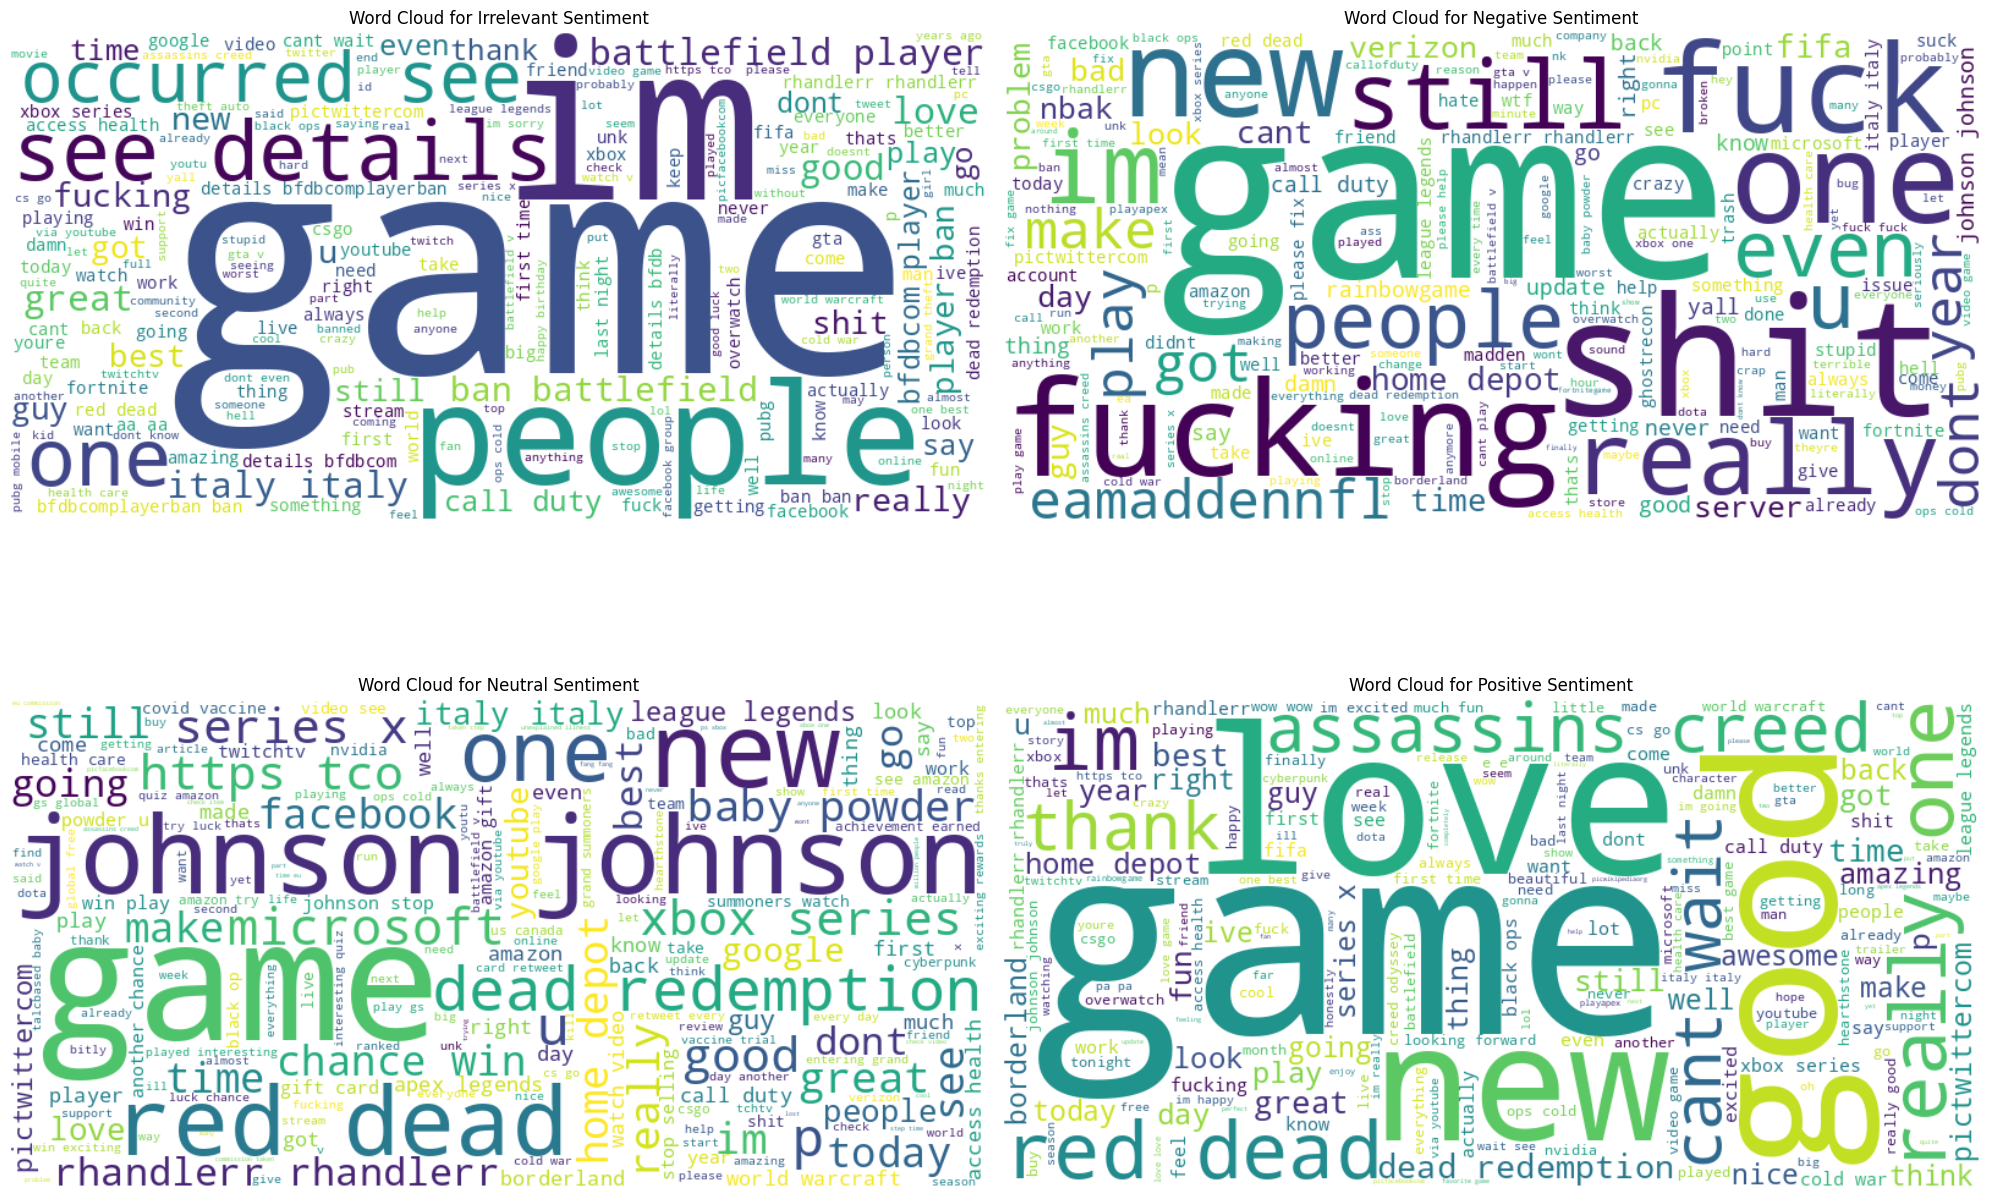

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Group processed text by sentiment
sentiment_texts = df.groupby('Sentiment')['processed_text'].apply(lambda x: ' '.join(x))

plt.figure(figsize=(20, 15))
for i, (sentiment, text) in enumerate(sentiment_texts.items()):
    if text:
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
        plt.subplot(2, 2, i + 1) # Adjust subplot grid based on number of sentiments
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.title(f'Word Cloud for {sentiment} Sentiment')
        plt.axis('off')

plt.tight_layout()
plt.show()


Top Entities per Sentiment:

--- Sentiment: Positive ---
Entity
AssassinsCreed               1446
Borderlands                  1019
Cyberpunk2077                 966
PlayStation5(PS5)             942
RedDeadRedemption(RDR)        930
CallOfDutyBlackopsColdWar     864
Hearthstone                   834
Nvidia                        816
Xbox(Xseries)                 792
HomeDepot                     780
Name: count, dtype: int64

--- Sentiment: Neutral ---
Entity
Amazon                    1236
WorldOfCraft              1068
johnson&johnson           1014
ApexLegends                942
Nvidia                     870
Microsoft                  846
Google                     822
LeagueOfLegends            822
RedDeadRedemption(RDR)     816
TomClancysGhostRecon       804
Name: count, dtype: int64

--- Sentiment: Negative ---
Entity
MaddenNFL               1710
NBA2K                   1476
FIFA                    1176
TomClancysRainbowSix    1122
Verizon                 1098
HomeDepot        

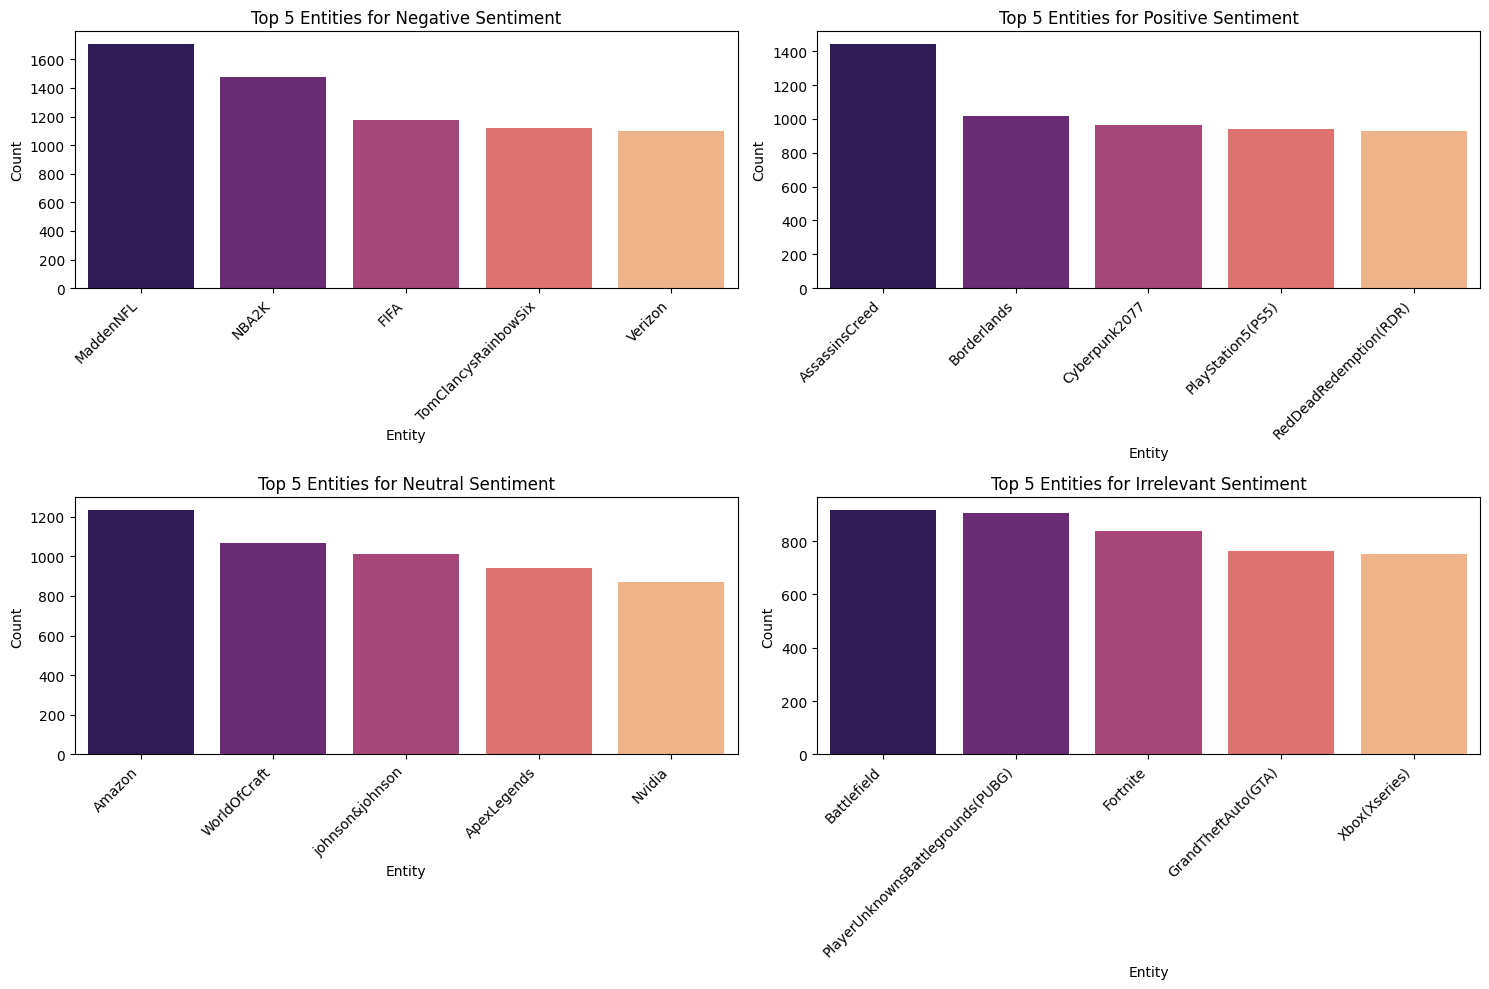

In [ ]:
print('\nTop Entities per Sentiment:')

for sentiment_label in df['Sentiment'].unique():
    print(f'\n--- Sentiment: {sentiment_label} ---')
    # Filter DataFrame for the current sentiment
    sentiment_df = df[df['Sentiment'] == sentiment_label]
    # Get the value counts for 'Entity' in this sentiment and display top 10
    entity_counts = sentiment_df['Entity'].value_counts().head(10)
    print(entity_counts)

# Optionally, visualize the top entities for each sentiment
plt.figure(figsize=(15, 10))
sentiment_order = df['Sentiment'].value_counts().index # Order by frequency

for i, sentiment_label in enumerate(sentiment_order):
    sentiment_df = df[df['Sentiment'] == sentiment_label]
    entity_counts = sentiment_df['Entity'].value_counts().head(5)

    plt.subplot(2, 2, i + 1) # Adjust subplot grid as needed
    sns.barplot(x=entity_counts.index, y=entity_counts.values, palette='magma', hue=entity_counts.index, legend=False)
    plt.title(f'Top 5 Entities for {sentiment_label} Sentiment')
    plt.xlabel('Entity')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()